# Reading Curatorial Identity Through Open Data
### National Gallery of Art, Washington D.C.

Museums present themselves as guardians of art history.
But every collection is also a cultural argument — shaped by
geography, patronage, and the values of its time.

This project asks: **can data reveal what a museum's choices mean?**

Using the National Gallery of Art's public dataset — 145,000+ artworks,
updated daily — this analysis traces three layers of curatorial identity:
the philosophy behind how art is organized, the artistic connections
the data reveals that the gallery floor conceals, and the private
patronage that made the collection possible in the first place.

This project is a reflection on what becomes possible when art,
data, and curiosity meet — and a tribute to the institutions that
make their collections openly available for exactly that kind of exploration.

---
*Data source: National Gallery of Art Open Data Program*  
*https://github.com/NationalGalleryOfArt/opendata*  
*License: Creative Commons Zero (CC0)*

In [1]:
# Connect Google Drive to access datasets
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import pandas as pd

# Load datasets from Google Drive
path = '/content/drive/MyDrive/national-gallery/'

constituents = pd.read_csv(path + 'constituents.csv', low_memory=False)
locations = pd.read_csv(path + 'locations.csv', low_memory=False)
obj_con = pd.read_csv(path + 'objects_constituents.csv', low_memory=False)
objects = pd.read_csv(path + 'objects.csv', low_memory=False)
preferred_loc = pd.read_csv(path + 'preferred_locations.csv', low_memory=False)
objects_terms = pd.read_csv(path + 'objects_terms.csv', low_memory=False)


# Verify datasets loaded correctly
print(f'constituents: {len(constituents):,} rows')
print(f'locations: {len(locations):,} rows')
print(f'objects_constituents: {len(obj_con):,} rows')
print(f'objects: {len(objects):,} rows')
print(f'preferred_locations: {len(preferred_loc):,} rows')
print(f'objects_terms: {len(objects_terms):,} rows')






constituents: 27,834 rows
locations: 1,168 rows
objects_constituents: 846,474 rows
objects: 145,656 rows
preferred_locations: 322 rows
objects_terms: 568,529 rows


## Finding 1: The NGA Organizes by National School, Not Chronology

Analysis of location data reveals that the West Building groups artworks
primarily by national origin — Italian, Spanish, Flemish, French, German —
rather than by strict chronological order.

This is a deliberate curatorial philosophy: the museum prioritizes
**where an artist came from** over **when they lived**.

- Titian (Italian, 1490–1576) → Galleries 11–25
- Velázquez (Spanish, 1599–1660) → Gallery 34
- Rubens (Flemish, 1577–1640) → Galleries 42–45

Note: Rubens was born before Velázquez, yet occupies higher-numbered
galleries — confirming the organization is by national school, not birth year.

In [12]:
# Explore objects_terms structure
print('Columns:', objects_terms.columns.tolist())
print()
print('Sample data:')
print(objects_terms.head(10).to_string())
print()
print('Term types:')
print(objects_terms['termtype'].value_counts().head(20))
# Filter only School terms — these are the curatorial classifications
schools = objects_terms[objects_terms['termtype'] == 'School']

print('Top curatorial schools in the NGA collection:')
print(schools['term'].value_counts().head(20).to_string())

Columns: ['termid', 'objectid', 'termtype', 'term', 'visualbrowsertheme', 'visualbrowserstyle']

Sample data:
    termid  objectid        termtype      term visualbrowsertheme visualbrowserstyle
0  2027419    204061         Keyword  Keywords                NaN                NaN
1  2027428    163360           Theme    Themes                NaN                NaN
2  2027428    184952           Theme    Themes                NaN                NaN
3  2027428    210273           Theme    Themes                NaN                NaN
4  2027440     12784  Place Executed  Illinois                NaN                NaN
5  2027440     14224  Place Executed  Illinois                NaN                NaN
6  2027440     14310  Place Executed  Illinois                NaN                NaN
7  2027440     14876  Place Executed  Illinois                NaN                NaN
8  2027440     14975  Place Executed  Illinois                NaN                NaN
9  2027440     15788  Place Executed  Il

In [14]:
# Cross curatorial school with gallery room
school_rooms = schools.merge(
    objects[['objectid', 'locationid']],
    on='objectid'
).merge(
    locations[['locationid', 'room']],
    on='locationid'
)

# Extract room number
school_rooms['room_number'] = school_rooms['room'].str.extract(r'M-0(\d+)').astype(float)

# Average room per school
avg_room_school = school_rooms[
    school_rooms['room_number'].notna()
].groupby('term')['room_number'].agg(['mean', 'count']).reset_index()
avg_room_school.columns = ['school', 'avg_gallery', 'works_on_display']
avg_room_school = avg_room_school[avg_room_school['works_on_display'] > 20]
avg_room_school = avg_room_school.sort_values('avg_gallery')

print(avg_room_school.to_string())

        school  avg_gallery  works_on_display
60     Sienese     5.372093                43
25  Florentine     9.103774               106
71    Venetian    21.574468                94
32      German    35.424242                33
62     Spanish    38.071429                28
24     Flemish    43.378378                37
18       Dutch    50.455357               112
10     British    60.447368                38
29      French    70.522727               220
0     American    70.604240               283


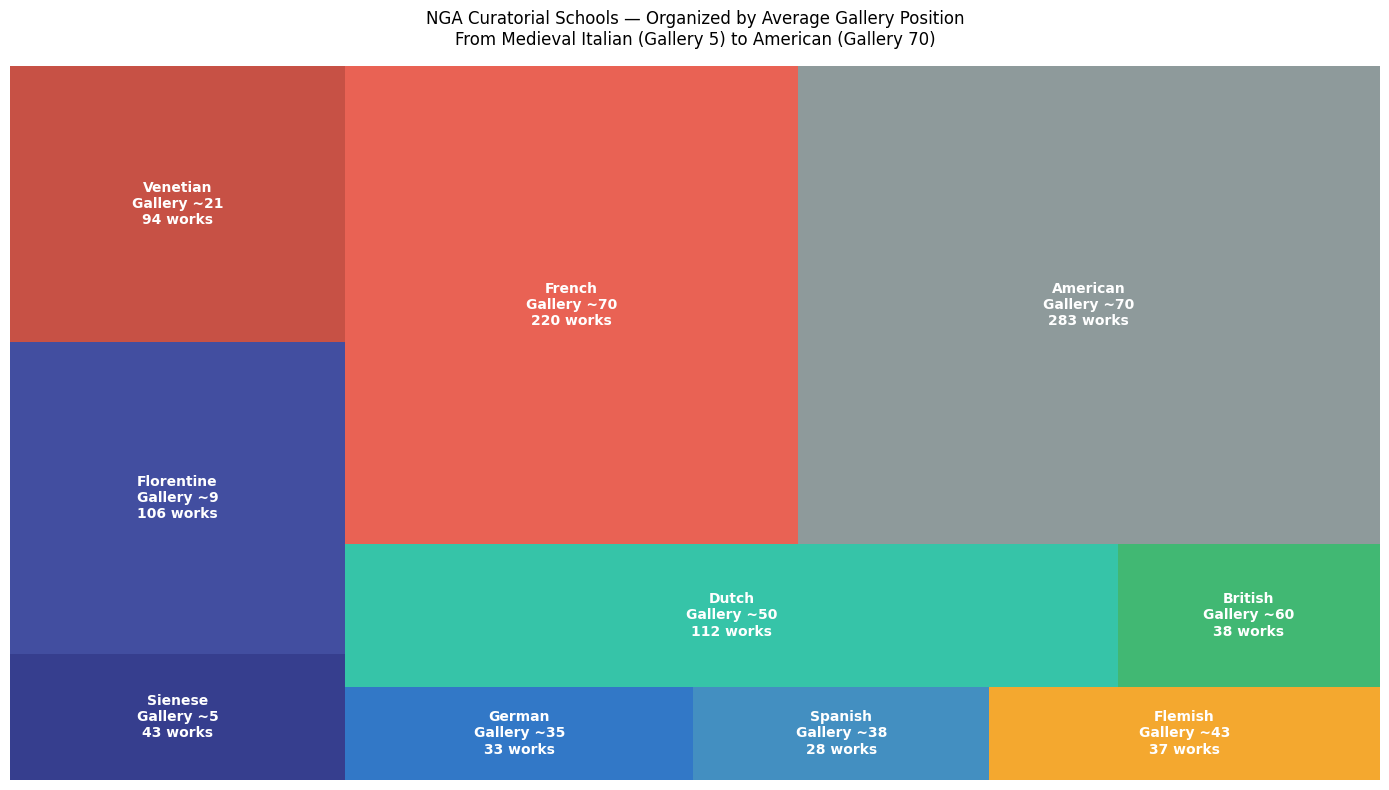

In [16]:
import squarify
import matplotlib.pyplot as plt

# Use only schools with enough works on display
plot_data = avg_room_school.sort_values('avg_gallery')

fig, ax = plt.subplots(figsize=(14, 8))

# Color gradient from dark to light based on gallery position (chronological)
colors = [
    '#1a237e',  # Sienese - darkest (oldest)
    '#283593',  # Florentine
    '#c0392b',  # Venetian — Titian
    '#1565c0',  # German
    '#2980b9',  # Spanish — Velázquez
    '#f39c12',  # Flemish — Rubens
    '#1abc9c',  # Dutch
    '#27ae60',  # British
    '#e74c3c',  # French
    '#7f8c8d',  # American - lightest (most recent)
]

labels = [
    f"{row['school']}\nGallery ~{int(row['avg_gallery'])}\n{row['works_on_display']} works"
    for _, row in plot_data.iterrows()
]

squarify.plot(
    sizes=plot_data['works_on_display'],
    label=labels,
    color=colors,
    alpha=0.88,
    ax=ax,
    text_kwargs={'fontsize': 10, 'color': 'white', 'fontweight': 'bold'}
)

ax.set_title('NGA Curatorial Schools — Organized by Average Gallery Position\n'
             'From Medieval Italian (Gallery 5) to American (Gallery 70)',
             fontsize=12, pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

## Finding 1: The NGA Organizes by Curatorial School — Confirmed by Data

Using the museum's own curatorial classifications from `objects_terms.csv`,
we can confirm that the West Building groups works by school — and that
these schools follow a broadly chronological progression through the galleries.

Each block represents a curatorial school as defined by the NGA itself:
- **Size** — number of works currently on display
- **Gallery number** — average gallery position in the West Building

The data reveals a clear progression:
Sienese (Gallery 5) -> Florentine (Gallery 9) -> Venetian (Gallery 21) -> Spanish (Gallery 38) -> Flemish (Gallery 43) -> Dutch (Gallery 50) -> French/American (Gallery 70)

This is not chronology imposed from outside — it is the museum's own
classification system made visible through data.

## Finding 2: Open Data Reveals Artistic Connections the Museum Doesn't Show

While the NGA organizes by curatorial school, the dataset itself documents
cross-school artistic influence — connections that are invisible to the
visitor on the gallery floor.

Titian (Venetian, Gallery 21) directly influenced both Velázquez (Spanish, Gallery 38)
and Rubens (Flemish, Gallery 43). This is documented in the collection data
through explicit attributions:

- *"Part of the Crowd at the Ecce Homo"* — Rubens working over an Italian copy after Titian
- *"Charles V, Emperor"* — a three-step chain: Titian -> Rubens -> Vorsterman

Significantly, the dataset contains **zero works** documenting
Velázquez copying Titian directly — a connection well established
by art historians but absent from this collection.

The data doesn't just reflect the museum's organization —
it also reflects which artistic conversations the collection chose to preserve.

In [17]:
# Search for works that explicitly reference Titian in their attribution
titian_influence = objects[
    objects['attribution'].str.contains('Titian', case=False, na=False)
][['objectid', 'title', 'attribution', 'displaydate']]

print(f'Works referencing Titian in attribution: {len(titian_influence)}')
print()

# Search for Rubens copying Titian specifically
rubens_after_titian = objects[
    objects['attribution'].str.contains('Rubens', case=False, na=False) &
    objects['attribution'].str.contains('Titian', case=False, na=False)
][['objectid', 'title', 'attribution', 'displaydate']]

print(f'Works where Rubens references Titian: {len(rubens_after_titian)}')
print(rubens_after_titian[['title', 'attribution', 'displaydate']].to_string())
print()

# Search for Velázquez copying Titian
velazquez_after_titian = objects[
    objects['attribution'].str.contains('Velázquez', case=False, na=False) &
    objects['attribution'].str.contains('Titian', case=False, na=False)
][['objectid', 'title', 'attribution', 'displaydate']]

print(f'Works where Velázquez references Titian: {len(velazquez_after_titian)}')

Works referencing Titian in attribution: 139

Works where Rubens references Titian: 2
                                     title                                                     attribution displaydate
94865   Part of the Crowd at the Ecce Homo       Sir Peter Paul Rubens over Anonymous Italian after Titian         NaN
101481                  Charles V, Emperor  Lucas Emil Vorsterman after Sir Peter Paul Rubens after Titian   1618-1620

Works where Velázquez references Titian: 0


## Finding 3: Private Collectors as the Foundation of Museum Collections

No major museum collection exists in isolation from private patronage.
The NGA's dataset makes this visible in a way that is rarely acknowledged
outside academic circles.

The top collectors by works in the collection:

- **Lessing Julius Rosenwald** — 48,975 works
- **Joseph E. Widener** — 4,186 works
- **Paul Mellon** — 2,522 works

These figures reveal something fundamental: curatorial identity is never
built by institutions alone. The vision, taste, and generosity of private
collectors defines what a museum can be — what periods it covers,
what schools it represents, what gaps it cannot fill.

The NGA exists because people believed art should be publicly accessible.
Open data simply makes that founding act visible in numbers.

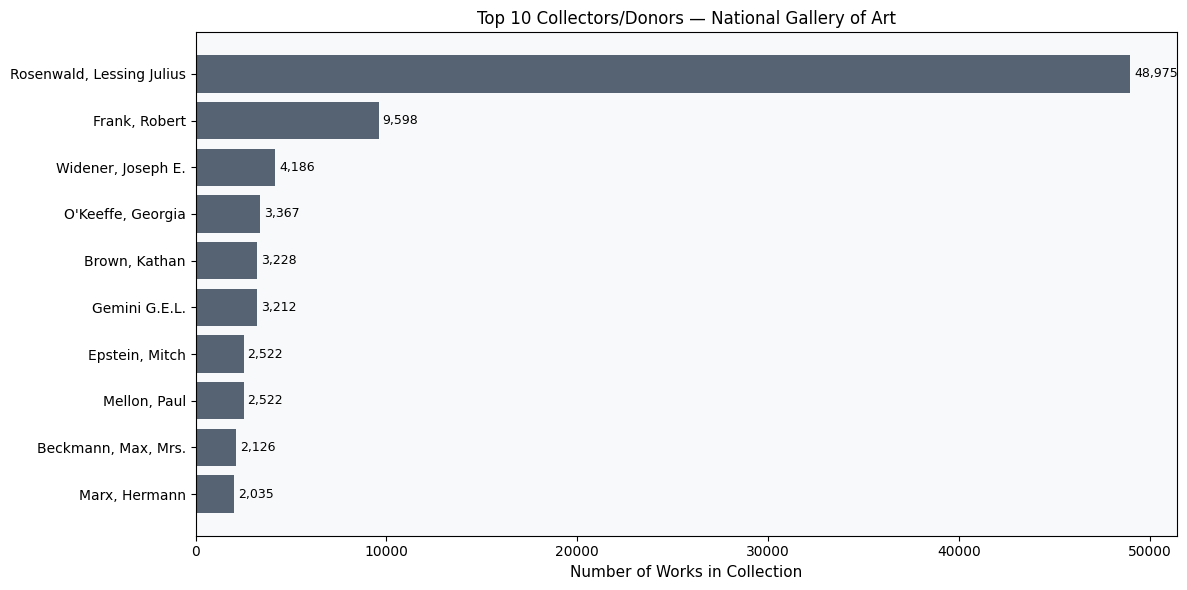

In [19]:
# Find top donors/collectors and how many works they contributed
donors = obj_con[
    obj_con['role'].str.contains('owner|donor|collector|gift', case=False, na=False)
].merge(
    constituents[['constituentid', 'preferreddisplayname', 'nationality']],
    on='constituentid'
).groupby(
    ['preferreddisplayname', 'nationality']
).size().reset_index(name='works').sort_values('works', ascending=False)

# Visualize top 10
import matplotlib.pyplot as plt

top_donors = donors.head(10)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(top_donors['preferreddisplayname'],
               top_donors['works'],
               color='#2c3e50', alpha=0.8)

ax.set_xlabel('Number of Works in Collection', fontsize=11)
ax.set_title('Top 10 Collectors/Donors — National Gallery of Art', fontsize=12)

for bar, val in zip(bars, top_donors['works']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#ffffff')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Conclusion

Museum collections are not neutral archives — they are cultural arguments.

Every organizational decision, every acquisition, every donation accepted
reflects a set of values: what art matters, whose history is worth preserving,
and how artistic influence is understood across cultures and centuries.

The NGA's open dataset makes these decisions readable for the first time
outside institutional walls. Through data, we can see that the museum
organizes by curatorial school with a broadly chronological progression,
that certain cross-cultural artistic conversations are documented but
spatially invisible, and that private collectors fundamentally
shaped what the collection is today.

None of this diminishes the museum — it contextualizes it.

Open data transforms collection records into a window onto
curatorial thinking — making visible the philosophy behind
every artistic decision a museum makes.

---

## Future Research

This project opens a larger question: **what happens when more museums
open their collections as data?**

A comparative analysis across institutions — the Prado, the Staatsgalerie,
the Louvre, the British Museum — would allow us to read curatorial philosophy
not as individual institutional choices but as a global cultural history.

We could begin to ask: how did world events shape what museums chose to show?
How did power, patronage, and geography define which artistic lineages
became visible and which were left in storage?

Open collection data is still rare. But as more institutions embrace
transparency, data analysis may become one of the most powerful tools
for understanding not just art history — but the history of how we
decide what art history looks like.

---

*Data source: National Gallery of Art Open Data Program*
*https://github.com/NationalGalleryOfArt/opendata*
*License: Creative Commons Zero (CC0)*
*Analysis by Carolina Reyes Velazquez, 2026*